# 1D charge-density comparison

This Julia Jupyter notebook compares every `site_density.csv` found below a downloaded campaign result directory. It also reports particle number, final energy, residuals, and bulk staggered density order.

It is analysis-only: it neither activates nor modifies the solver environment.

## Local setup

After downloading the campaign result directory from the cluster, create a separate local plotting environment:

```bash
ANALYSIS_ENV="$HOME/julia-analysis-envs/mpo_density"
mkdir -p "$ANALYSIS_ENV"
julia --project="$ANALYSIS_ENV" -e 'using Pkg; Pkg.add(["IJulia", "CairoMakie"])'
julia --project="$ANALYSIS_ENV" -e "using IJulia; installkernel(\"Julia MPO density\"; env=Dict(\"JULIA_PROJECT\" => \"$ANALYSIS_ENV\"))"
```

Then open this notebook with your usual Jupyter or VS Code interface, select the `Julia MPO density` kernel, and set `result_root` in the next code cell.

In [16]:
using CairoMakie
using Statistics
using TOML
using FFTW

In [41]:
results_root = joinpath(ENV["HOME"], "MPO_HF_analysis", "results")

mpo_root = joinpath(results_root, "aubry_andre_nn_l10_seed0p1")
dense_root = joinpath(results_root, "aubry_andre_nn_l10_seed0p1_dense_hf")

"/Users/nicolausobrosa/MPO_HF_analysis/results/aubry_andre_nn_l10_seed0p1_dense_hf"

In [4]:
unquote(value::AbstractString) = strip(strip(value), '"')

function read_site_density(path::AbstractString)
    lines = readlines(path)
    isempty(lines) && error("empty density CSV: $path")
    strip(lines[1]) == "\"site\",\"density\"" || error("unexpected header in $path")
    sites, density = Int[], Float64[]
    for line in Iterators.drop(lines, 1)
        isempty(strip(line)) && continue
        columns = split(strip(line), ','; limit=2)
        length(columns) == 2 || error("malformed density row: $line")
        push!(sites, parse(Int, unquote(columns[1])))
        push!(density, parse(Float64, unquote(columns[2])))
    end
    sites == collect(1:length(sites)) || error("site indices are not contiguous in $path")
    return sites, density
end

function bulk_staggered_order(sites, density; edge_fraction=0.1)
    N = length(sites)
    bulk = (floor(Int, edge_fraction * N) + 1):(N - floor(Int, edge_fraction * N))
    mean((isodd(sites[i]) ? 1.0 : -1.0) * (density[i] - 0.5) for i in bulk)
end

function load_campaign(root::AbstractString)
    isdir(root) || error("result_root is not a directory: $root")
    task_dirs = sort(filter(path -> isdir(path) && isfile(joinpath(path, "site_density.csv")), readdir(root; join=true)))
    isempty(task_dirs) && error("no task directories with site_density.csv below $root")
    map(task_dirs) do directory
        sites, density = read_site_density(joinpath(directory, "site_density.csv"))
        obs = TOML.parsefile(joinpath(directory, "observables.toml"))
        (label=replace(basename(directory), r"^task_\d+_" => ""), sites=sites, density=density, observables=obs, bulk_staggered_order=bulk_staggered_order(sites, density))
    end
end

load_campaign (generic function with 1 method)

In [42]:
mpo_cases = Dict(entry.label => entry for entry in load_campaign(mpo_root))
dense_cases = Dict(entry.label => entry for entry in load_campaign(dense_root))

@assert keys(mpo_cases) == keys(dense_cases)
labels = sort(collect(keys(mpo_cases)))

summary = [(
    case=entry.label,
    N=length(entry.sites),
    particle_number=get(entry.observables, "particle_number", missing),
    energy_total=get(entry.observables, "energy_total", missing),
    idempotency=get(entry.observables, "idempotency_residual", missing),
    stationarity=get(entry.observables, "stationarity_residual", missing),
    bulk_staggered_order=entry.bulk_staggered_order,
) for entry in cases]

summary

3-element Vector{@NamedTuple{case::String, N::Int64, particle_number::Float64, energy_total::Float64, idempotency::Float64, stationarity::Float64, bulk_staggered_order::Float64}}:
 (case = "v2_0_u_1", N = 1024, particle_number = 511.9999717683668, energy_total = -500.54933250650737, idempotency = 1.0402035912781315e-6, stationarity = 3.0418680974933017e-6, bulk_staggered_order = -0.0832159816074936)
 (case = "v2_0p5_u_1", N = 1024, particle_number = 512.0000182031283, energy_total = -547.4921769914655, idempotency = 1.3650634906591523e-6, stationarity = 6.196895112399874e-6, bulk_staggered_order = -0.12280761293876885)
 (case = "v2_2_u_0p2", N = 1024, particle_number = 511.99994459074446, energy_total = -1095.9748638555793, idempotency = 0.0001526333665981322, stationarity = 0.0007188164116554365, bulk_staggered_order = -0.01736958220529671)

## Full density and central-window view

The upper panel exposes boundary response. The lower panel magnifies a central window: persistent even/odd splitting there is a bulk Hartree--Fock CDW branch, while splitting that decays toward the centre is boundary Friedel response.

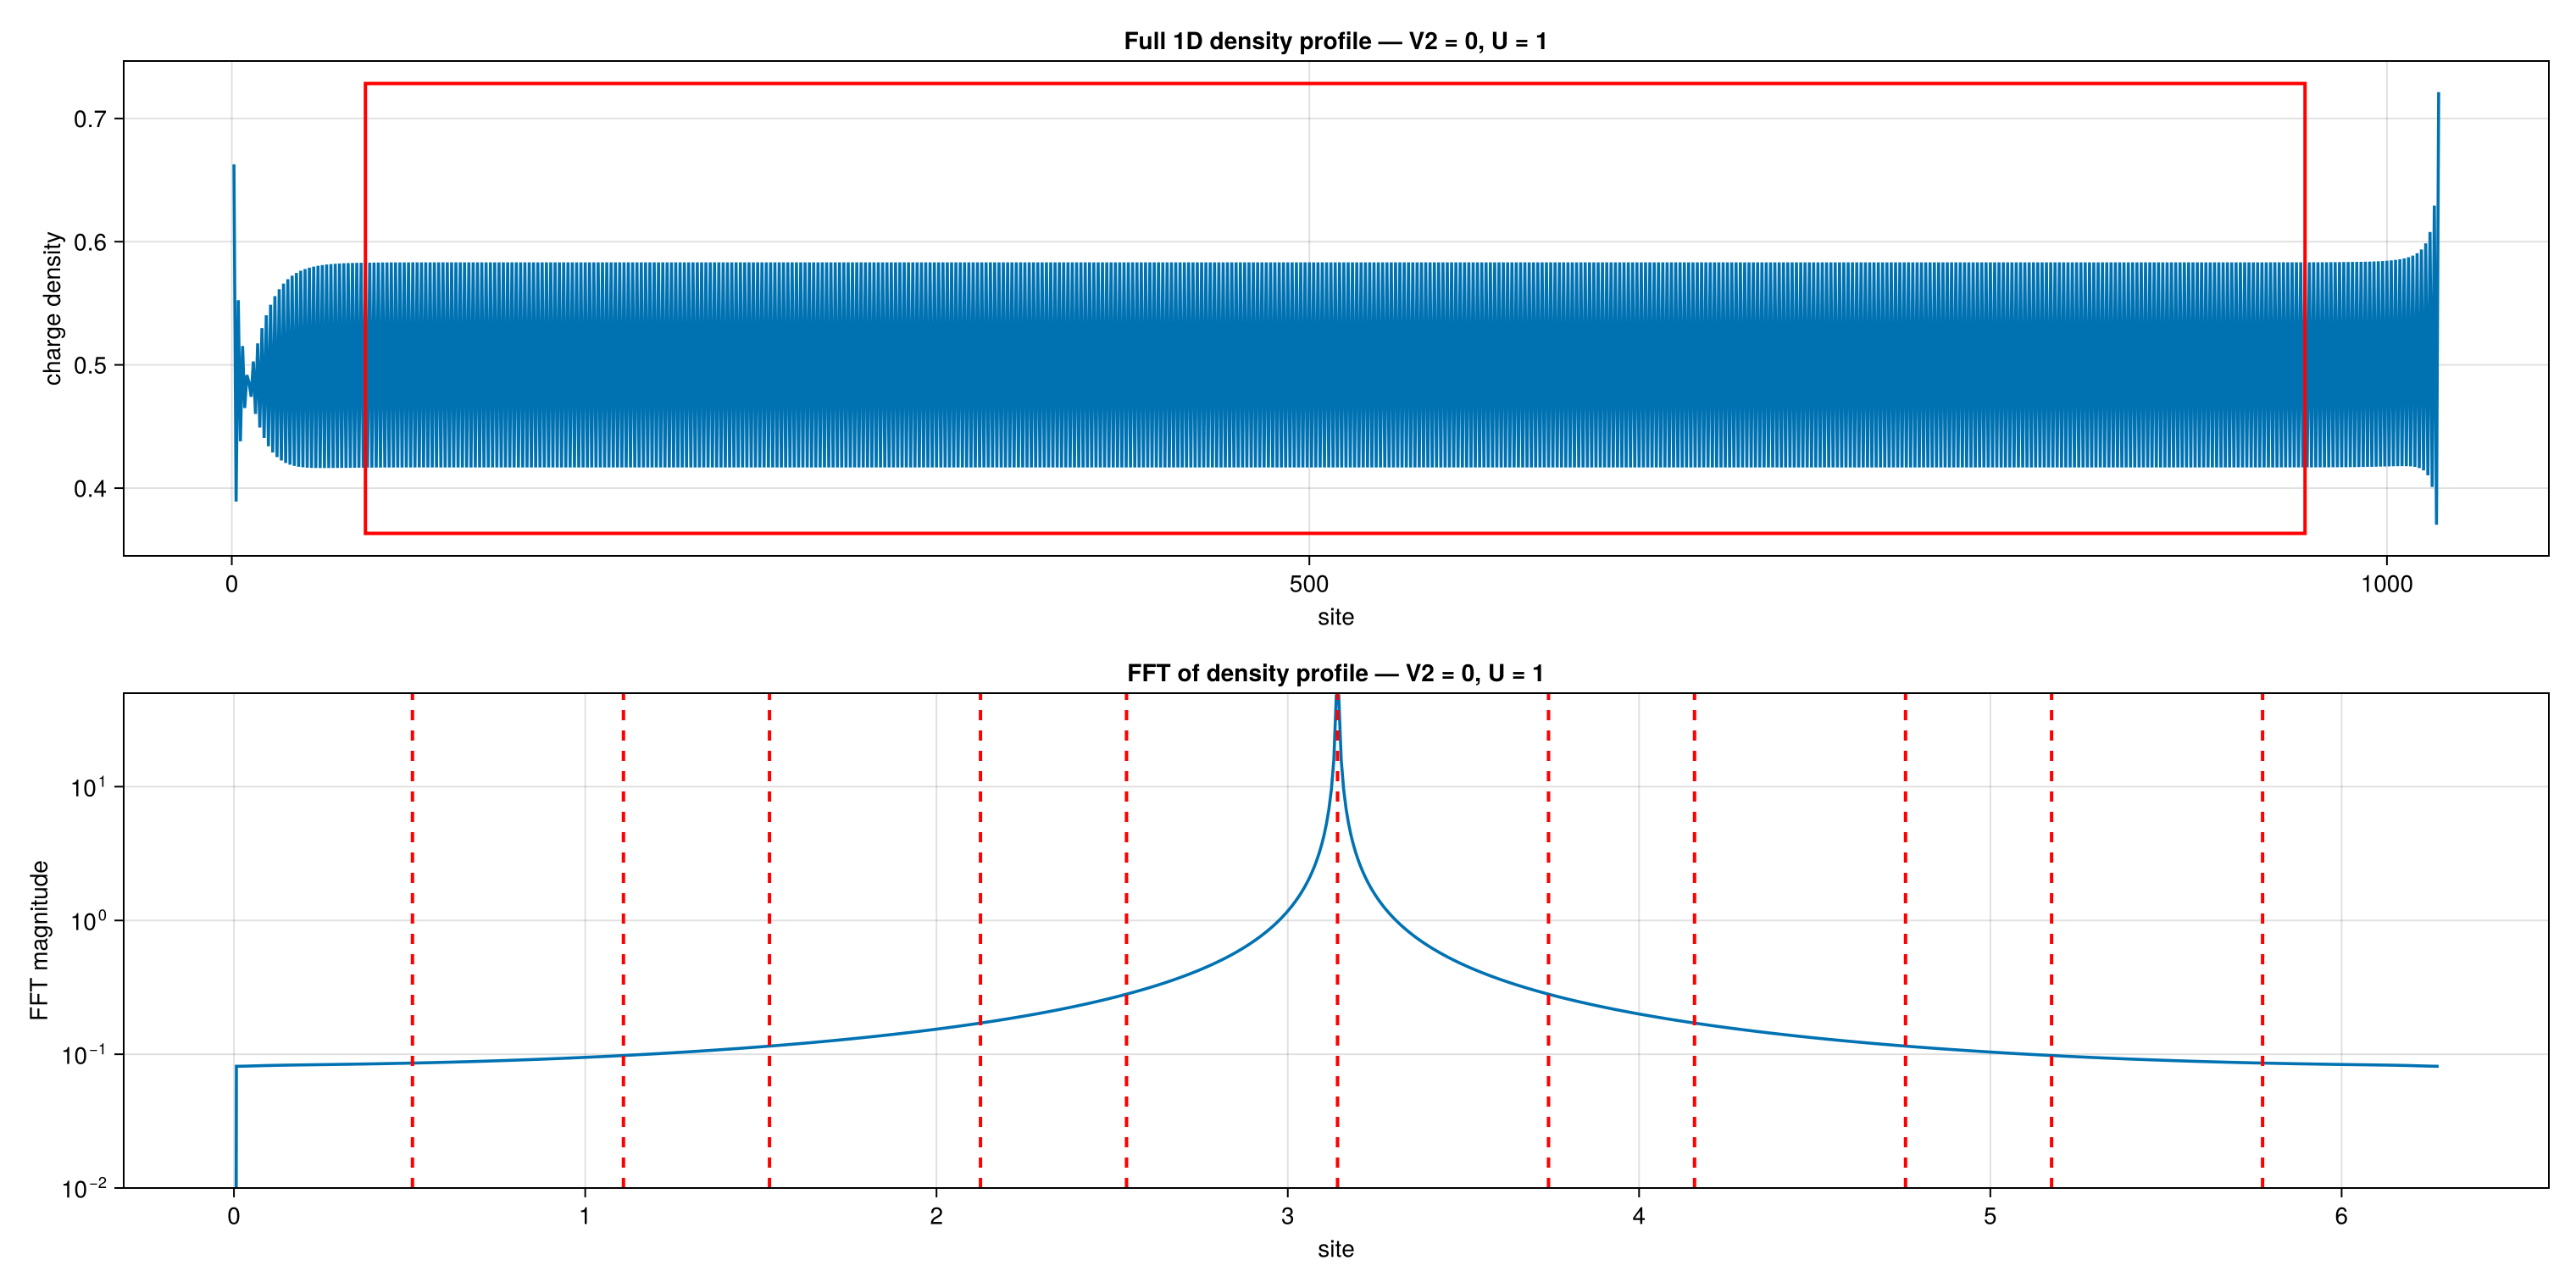

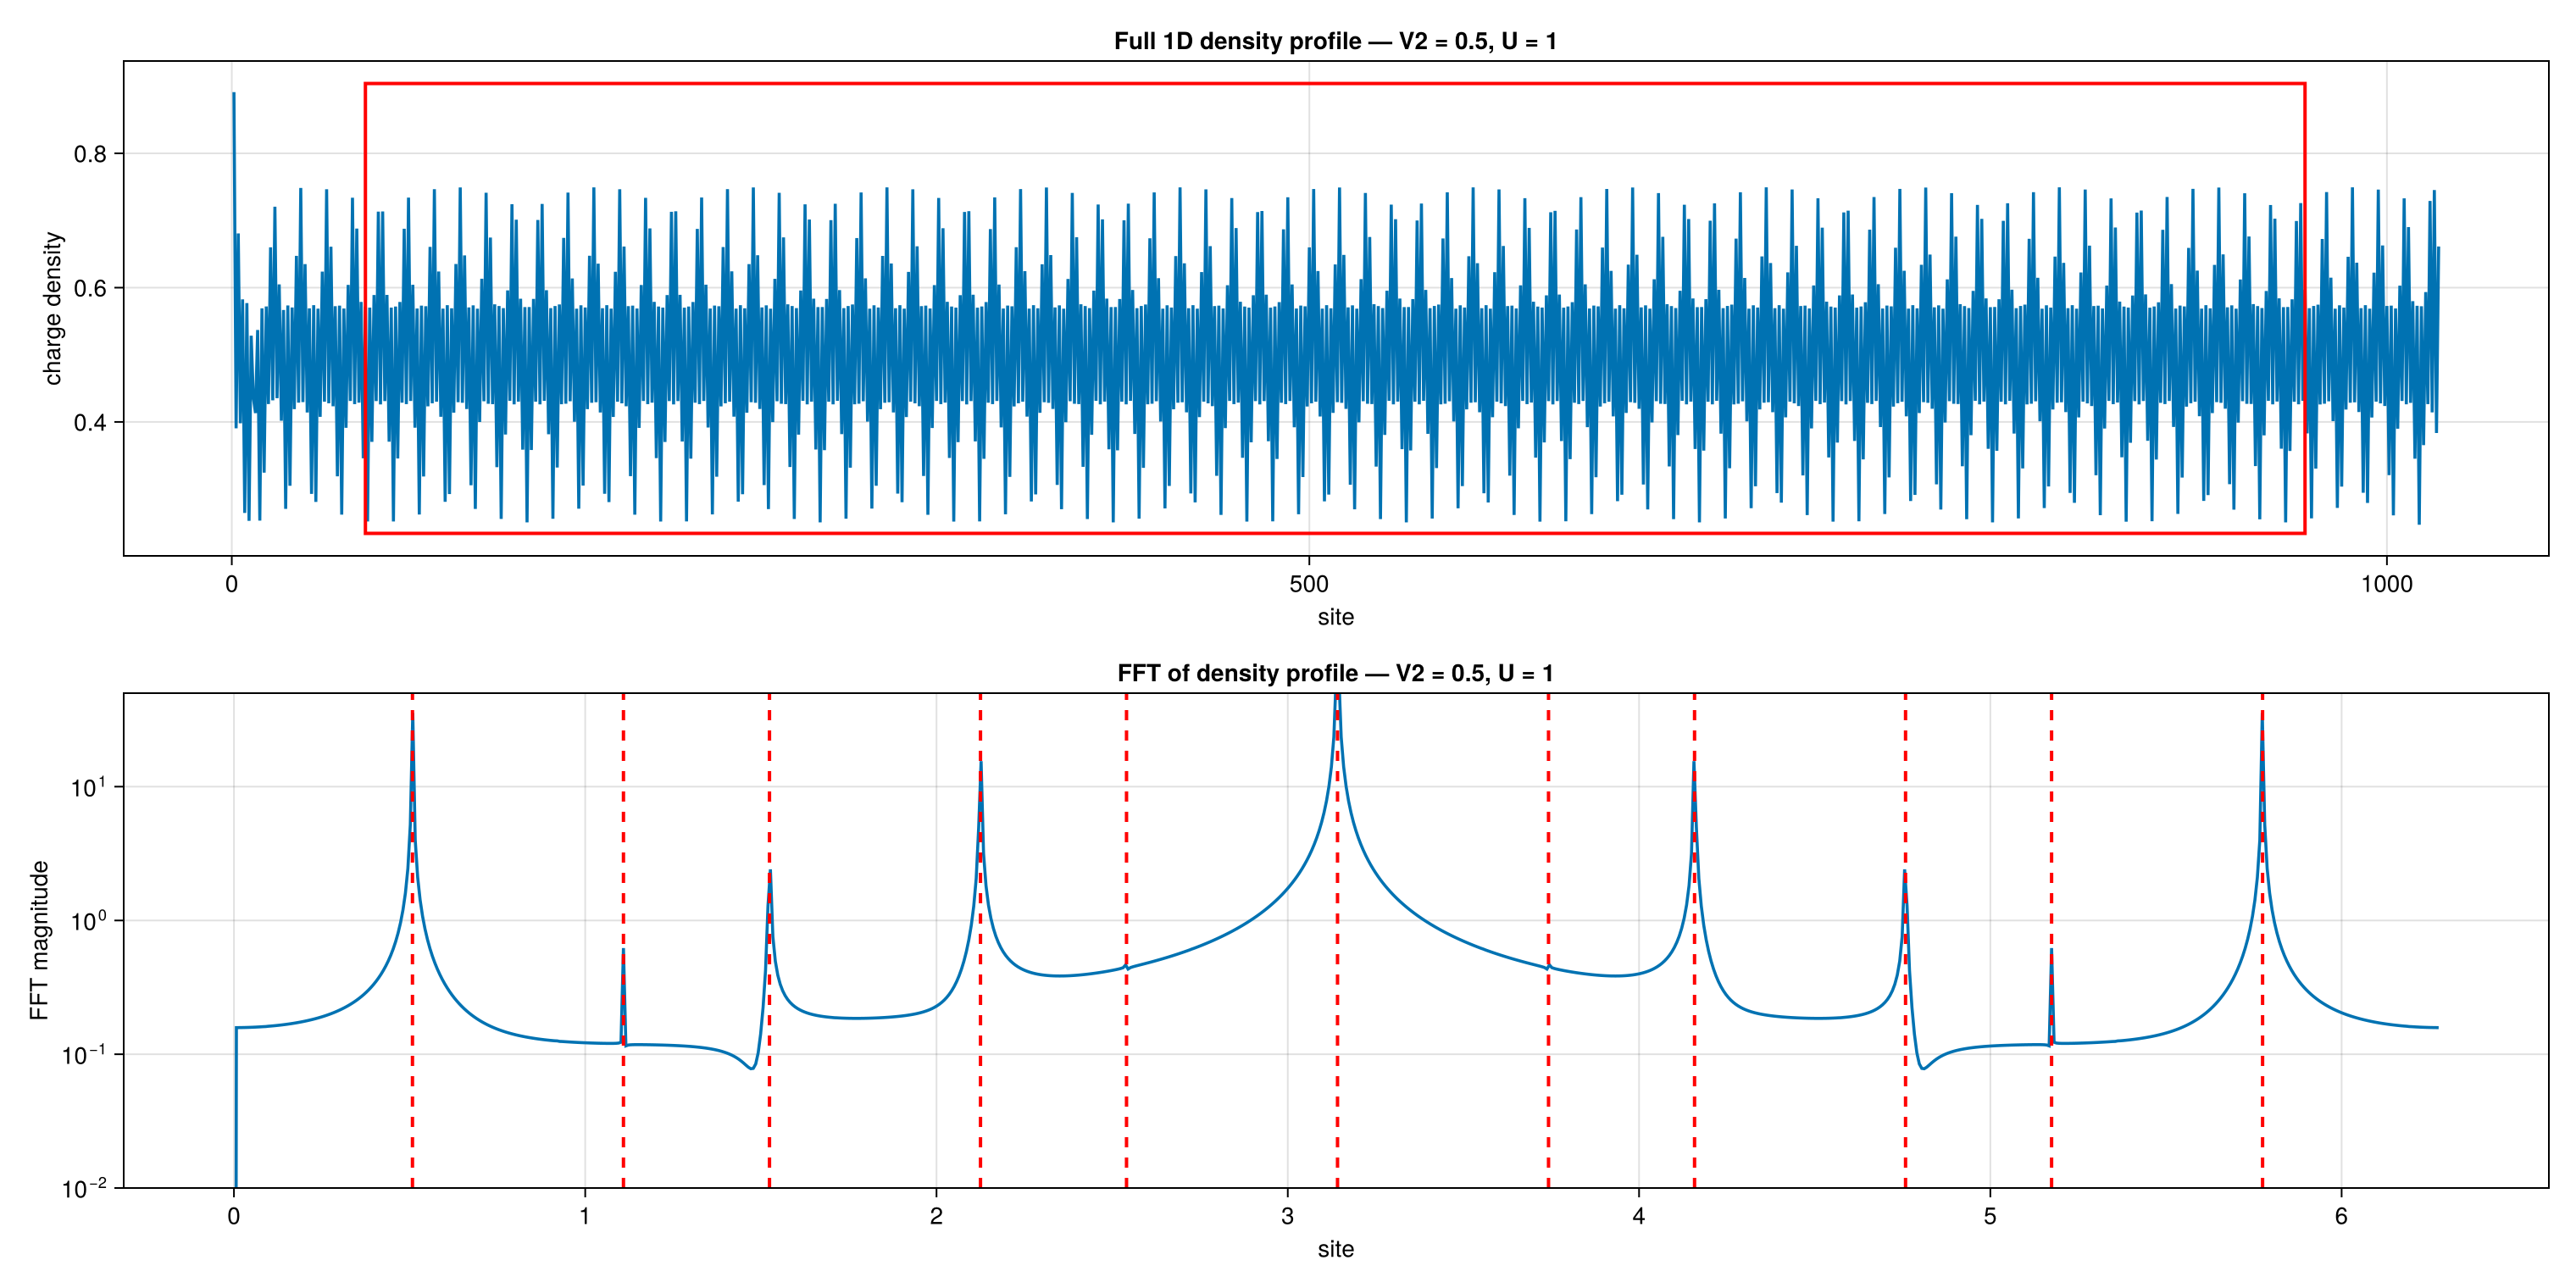

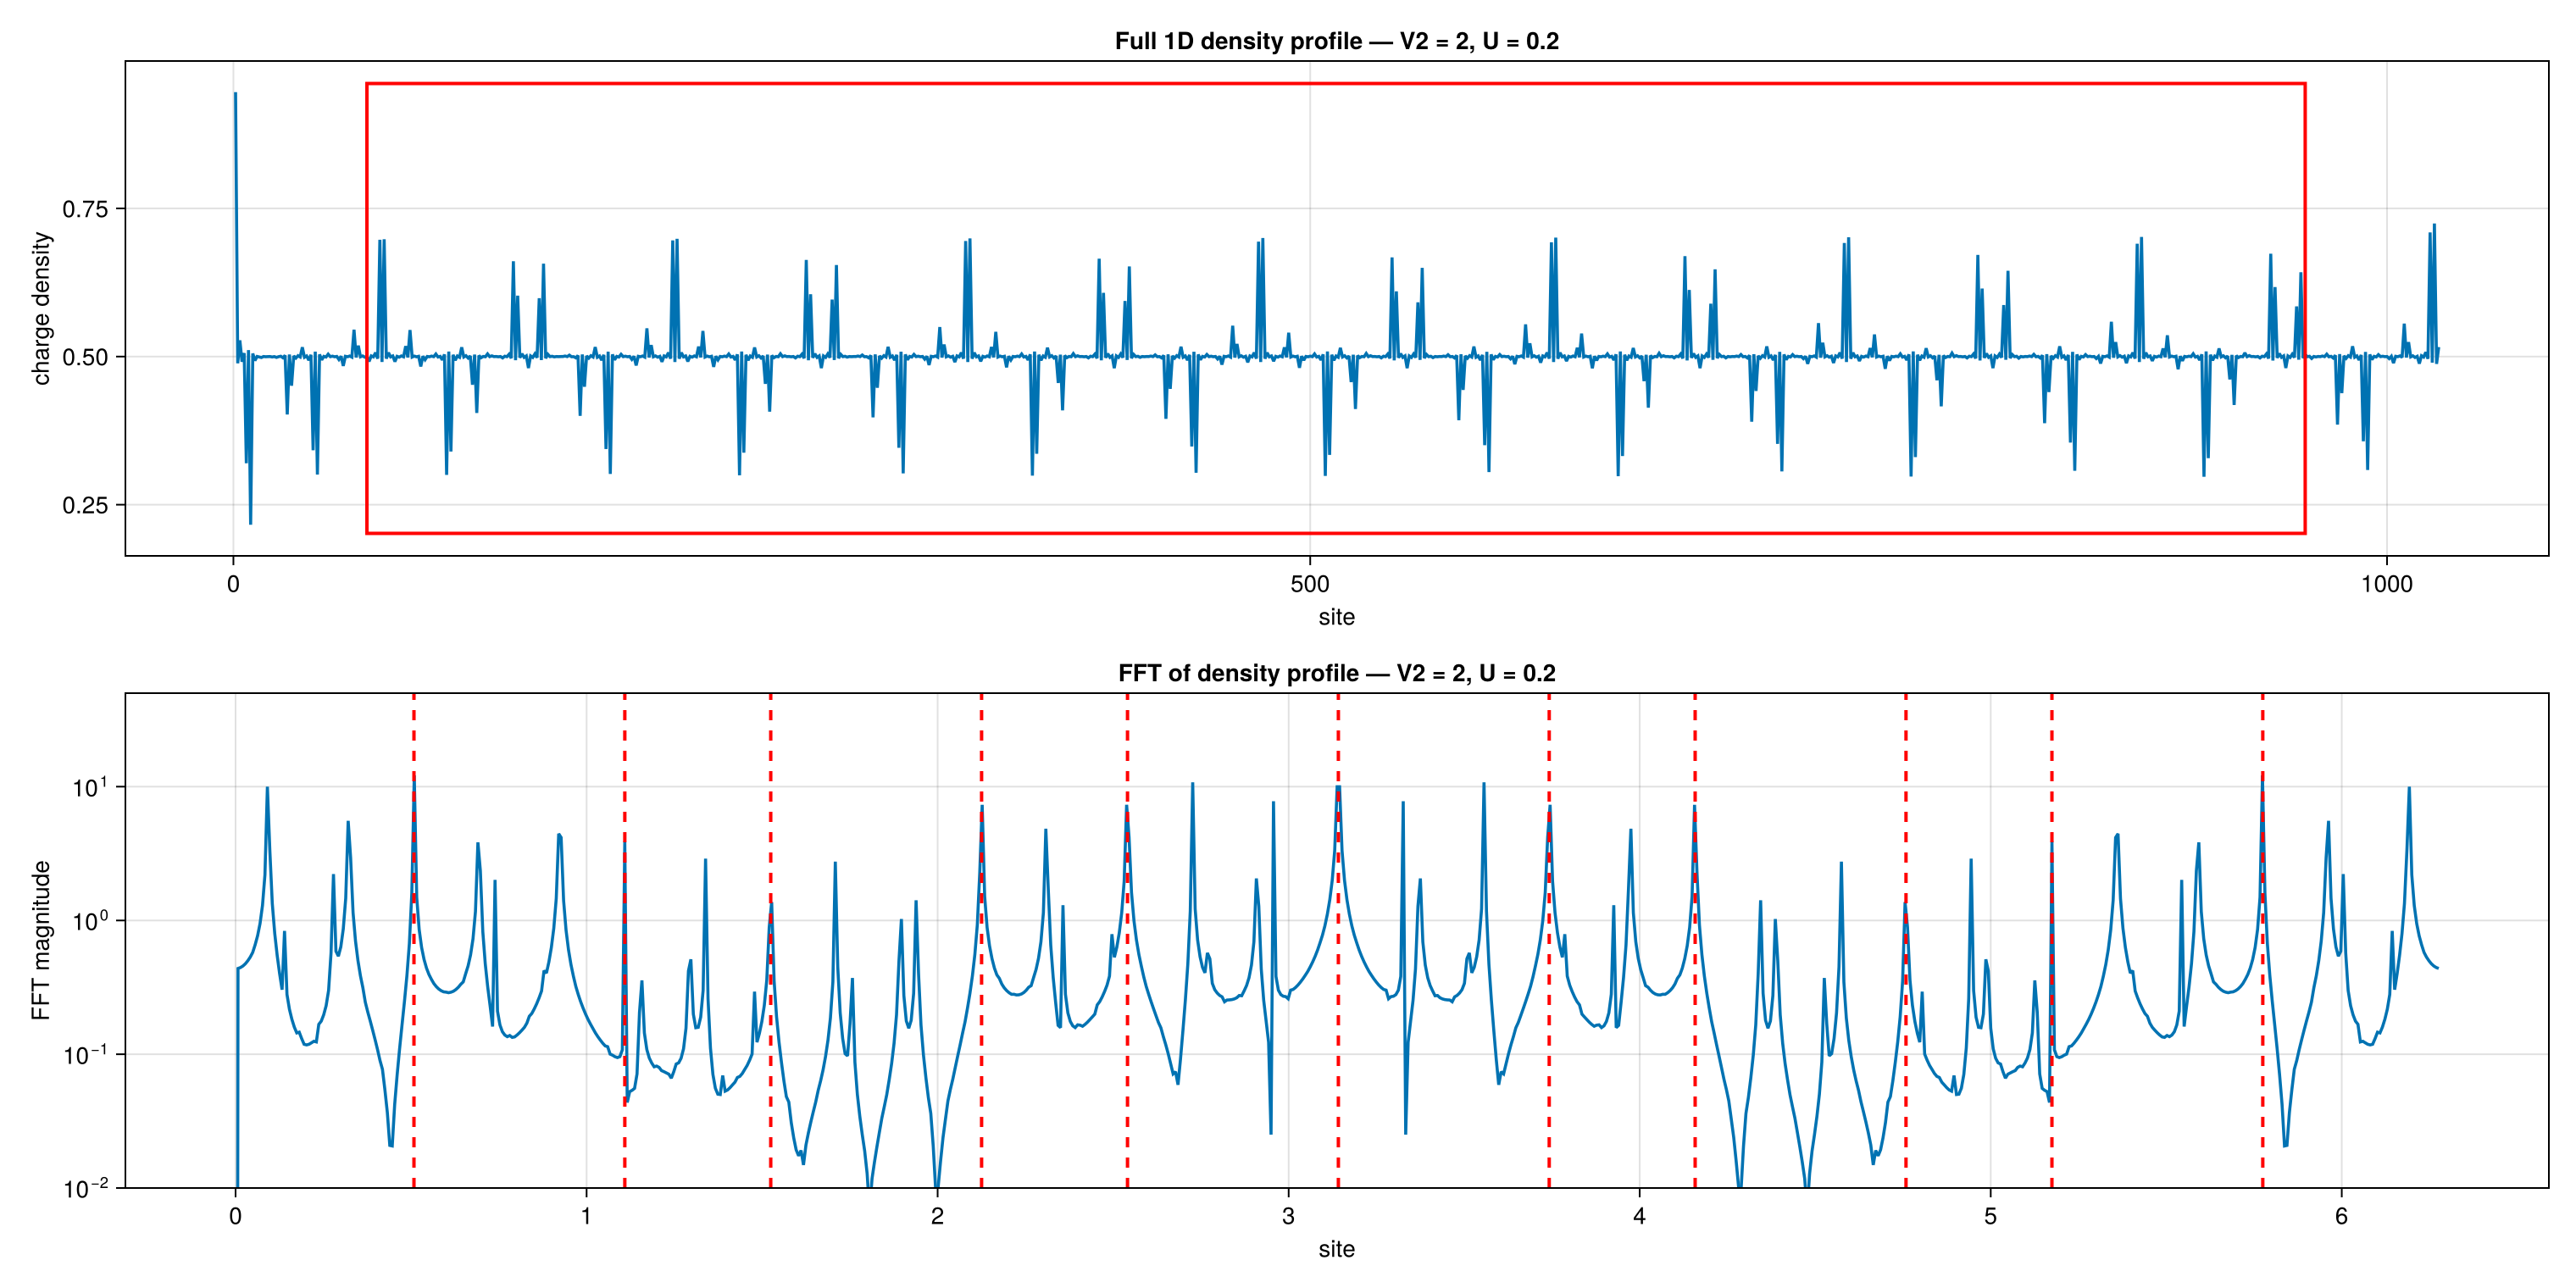

In [39]:
function parse_case_labels(lbl::AbstractString)
    parts = split(lowercase(lbl), '_')
    vals = Dict{String,String}()
    for i in 1:length(parts)-1
        key = parts[i]
        if key in ("v2", "u")
            raw = replace(parts[i+1], 'p'=>'.')
            num = tryparse(Float64, raw)
            if num === nothing
                vals[key] = raw
            else
                if isapprox(num, round(num); atol=1e-12)
                    vals[key] = string(Int(round(num)))
                else
                    vals[key] = string(num)
                end
            end
        end
    end
    return ["V2 = " * get(vals, "v2", "?"), "U = " * get(vals, "u", "?")]
end

titles_map = Dict(entry.label => parse_case_labels(entry.label) for entry in cases)

for entry in cases
    CairoMakie.activate!()
    fig = Figure(size=(760*2, 760))
    full_axis = Axis(fig[1, 1], xlabel="site", ylabel="charge density",
                     title="Full 1D density profile — $(titles_map[entry.label][1]), $(titles_map[entry.label][2])")


    fft_axis = Axis(fig[2, 1], xlabel="site", ylabel="FFT magnitude", yscale=log10, limits=(nothing, nothing, 1e-2,50),
                    title="FFT of density profile — $(titles_map[entry.label][1]), $(titles_map[entry.label][2])")
    lines!(full_axis, entry.sites, entry.density; linewidth=1.8)
    center = cld(length(entry.sites), 2)
    half_width = min(450, center - 1, length(entry.sites) - center)
    window = (center - half_width):(center + half_width)



    ns_fft = abs.(fft(entry.density[window] .- mean(entry.density[window])))
    lines!(fft_axis, LinRange(0,2pi - 2pi/length(ns_fft),length(ns_fft)), ns_fft; linewidth=1.8)

    # Draw rectangle on full plot to mark the central window
    x1 = entry.sites[first(window)]
    x2 = entry.sites[last(window)]
    y_min = minimum(entry.density)
    y_max = maximum(entry.density)
    pad = max(1e-6, 0.02 * (y_max - y_min))
    y_min -= pad
    y_max += pad
    xs = [x1, x2, x2, x1, x1]
    ys = [y_min, y_min, y_max, y_max, y_min]
    lines!(full_axis, xs, ys; color=:red, linewidth=2)
    tau = sqrt(2) - 5/6
    ks = []
    for i in -5:5
        k0 = mod2pi(pi + tau * 2pi * i)
        push!(ks, k0)
    end
    vlines!(fft_axis, ks; color=:red, linestyle=:dash, linewidth=2)
    display(fig)
end

In [45]:
comparison = [begin
    mpo = mpo_cases[label]
    dense = dense_cases[label]
    Δn = mpo.density .- dense.density

    (
        case = label,
        particle_number_mpo = mpo.observables["particle_number"],
        particle_number_dense = dense.observables["particle_number"],
        energy_mpo = mpo.observables["energy_total"],
        energy_dense = dense.observables["energy_total"],
        density_max_abs_error = maximum(abs.(Δn)),
        density_rms_error = sqrt(mean(abs2, Δn)),
        mpo_bulk_cdw = mpo.bulk_staggered_order,
        dense_bulk_cdw = dense.bulk_staggered_order,
    )
end for label in labels]

comparison

println("Comparison of MPO and dense HF results:")
println("------------------------------------------------")
println("Case\tdensity max abs error\tDensity RMS error\tMPO bulk CDW\tDense bulk CDW")
for entry in comparison
    println("$(entry.case)\t$(entry.density_max_abs_error)\t$(entry.density_rms_error)\t$(entry.mpo_bulk_cdw)\t$(entry.dense_bulk_cdw)")
end

Comparison of MPO and dense HF results:
------------------------------------------------
Case	density max abs error	Density RMS error	MPO bulk CDW	Dense bulk CDW
v2_0_u_1	2.639303092355494e-6	4.740291210487069e-7	-0.0832159816074936	-0.08321614479101203
v2_0p5_u_1	8.612319718159789e-6	7.328294915379099e-7	-0.12280761293876885	-0.12280757003517741
v2_2_u_0p2	0.003741645464738985	0.00023771727363780927	-0.01736958220529671	-0.01737012856851912


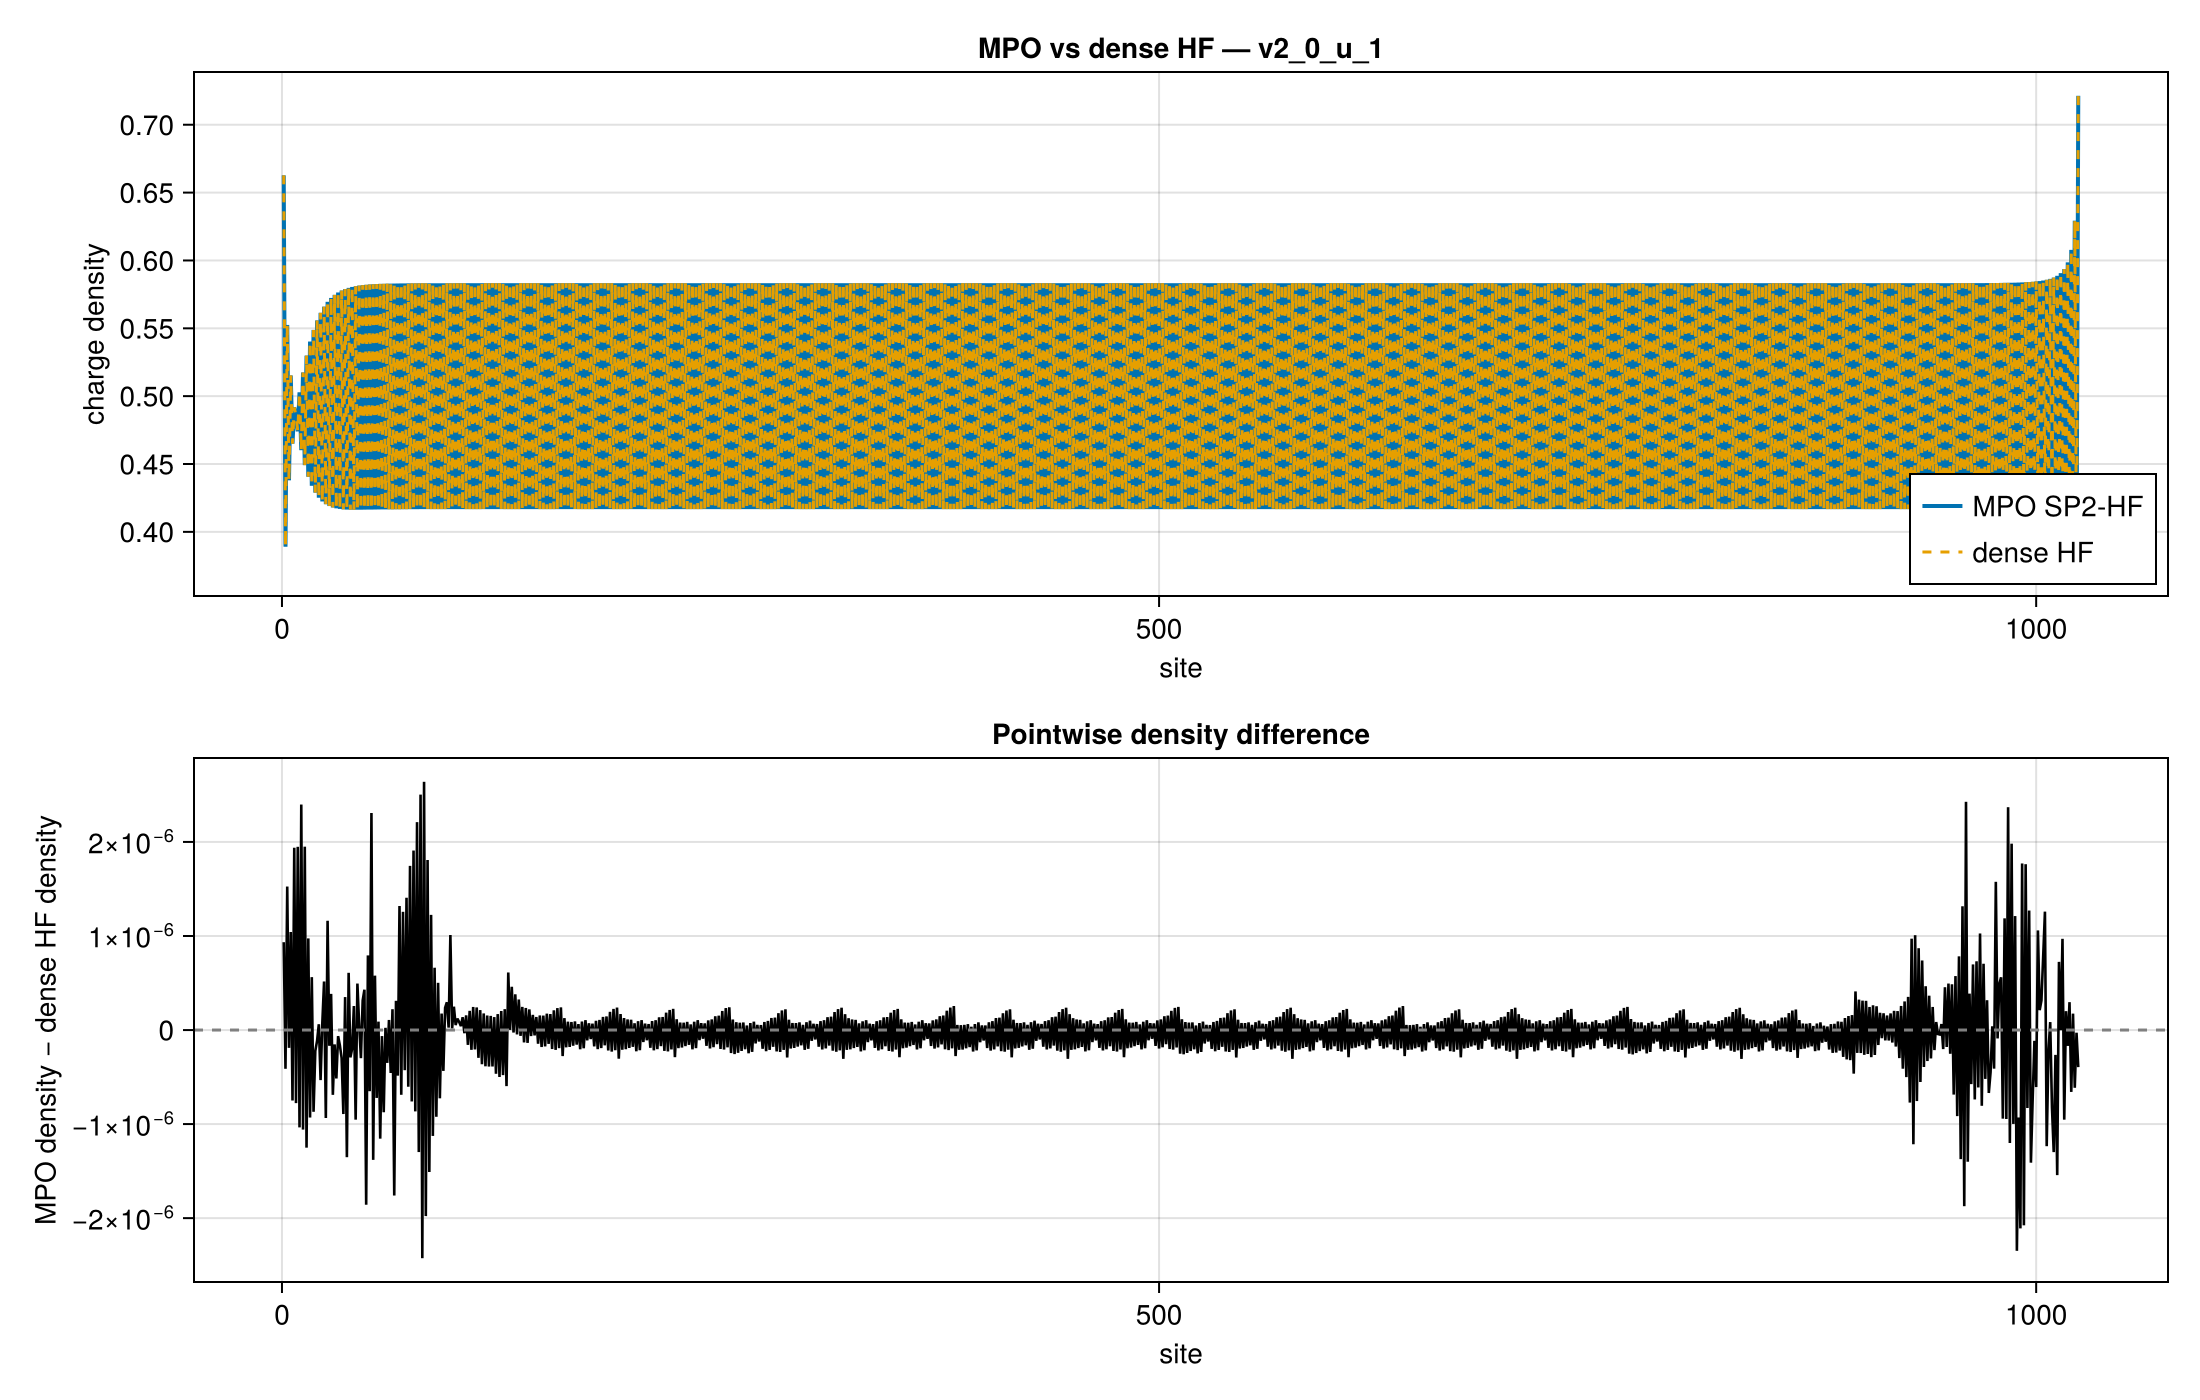

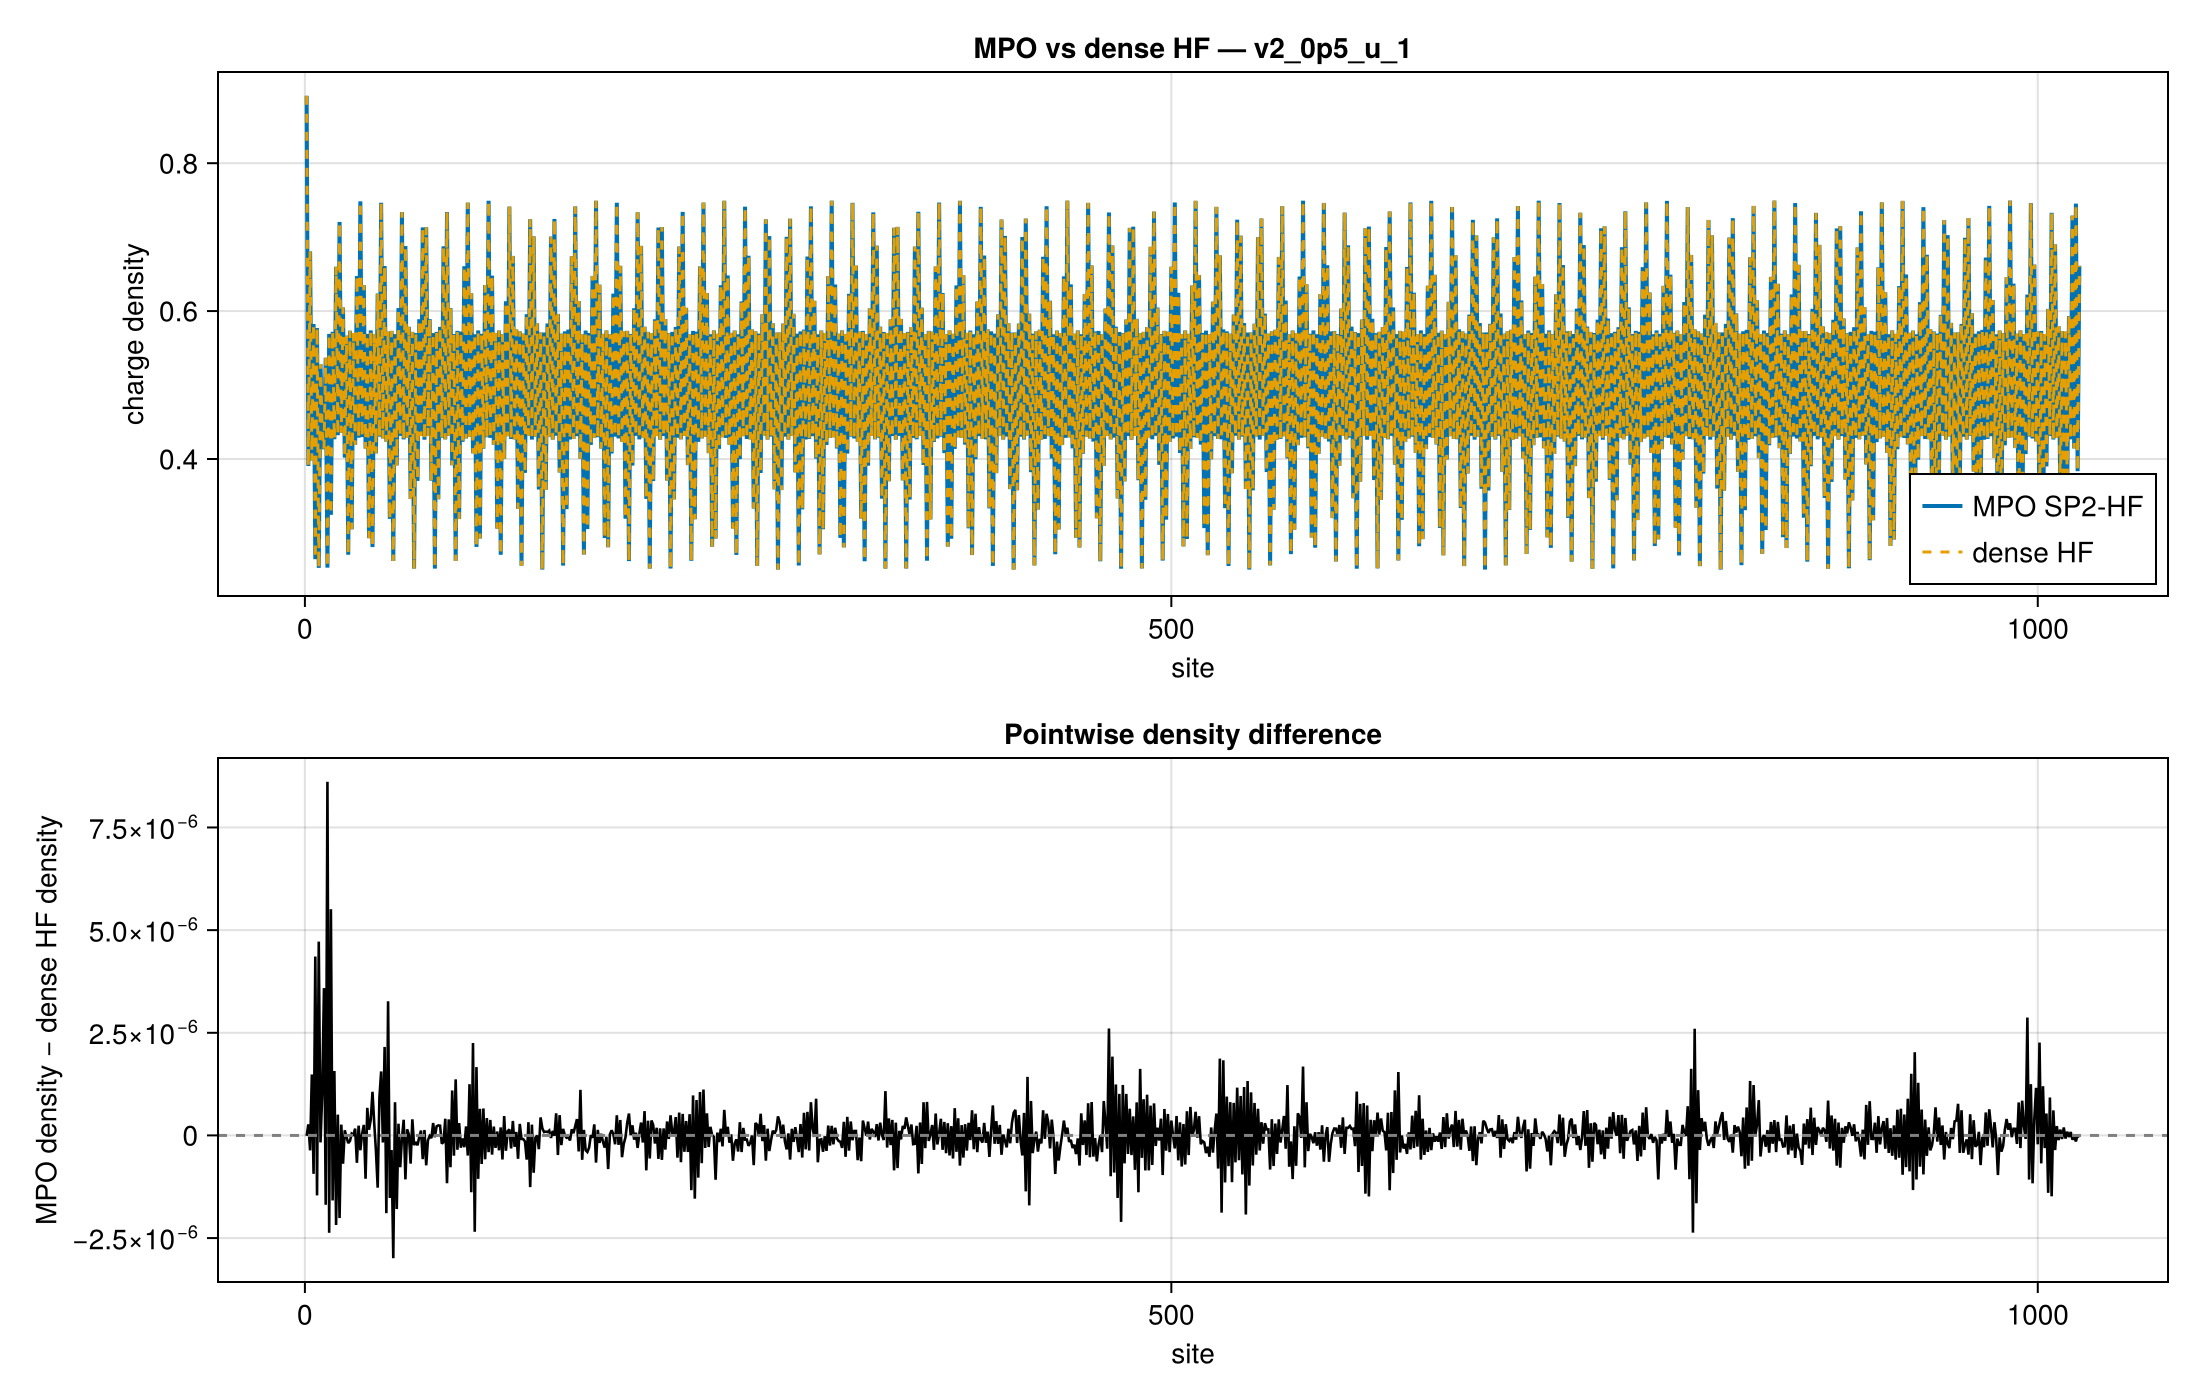

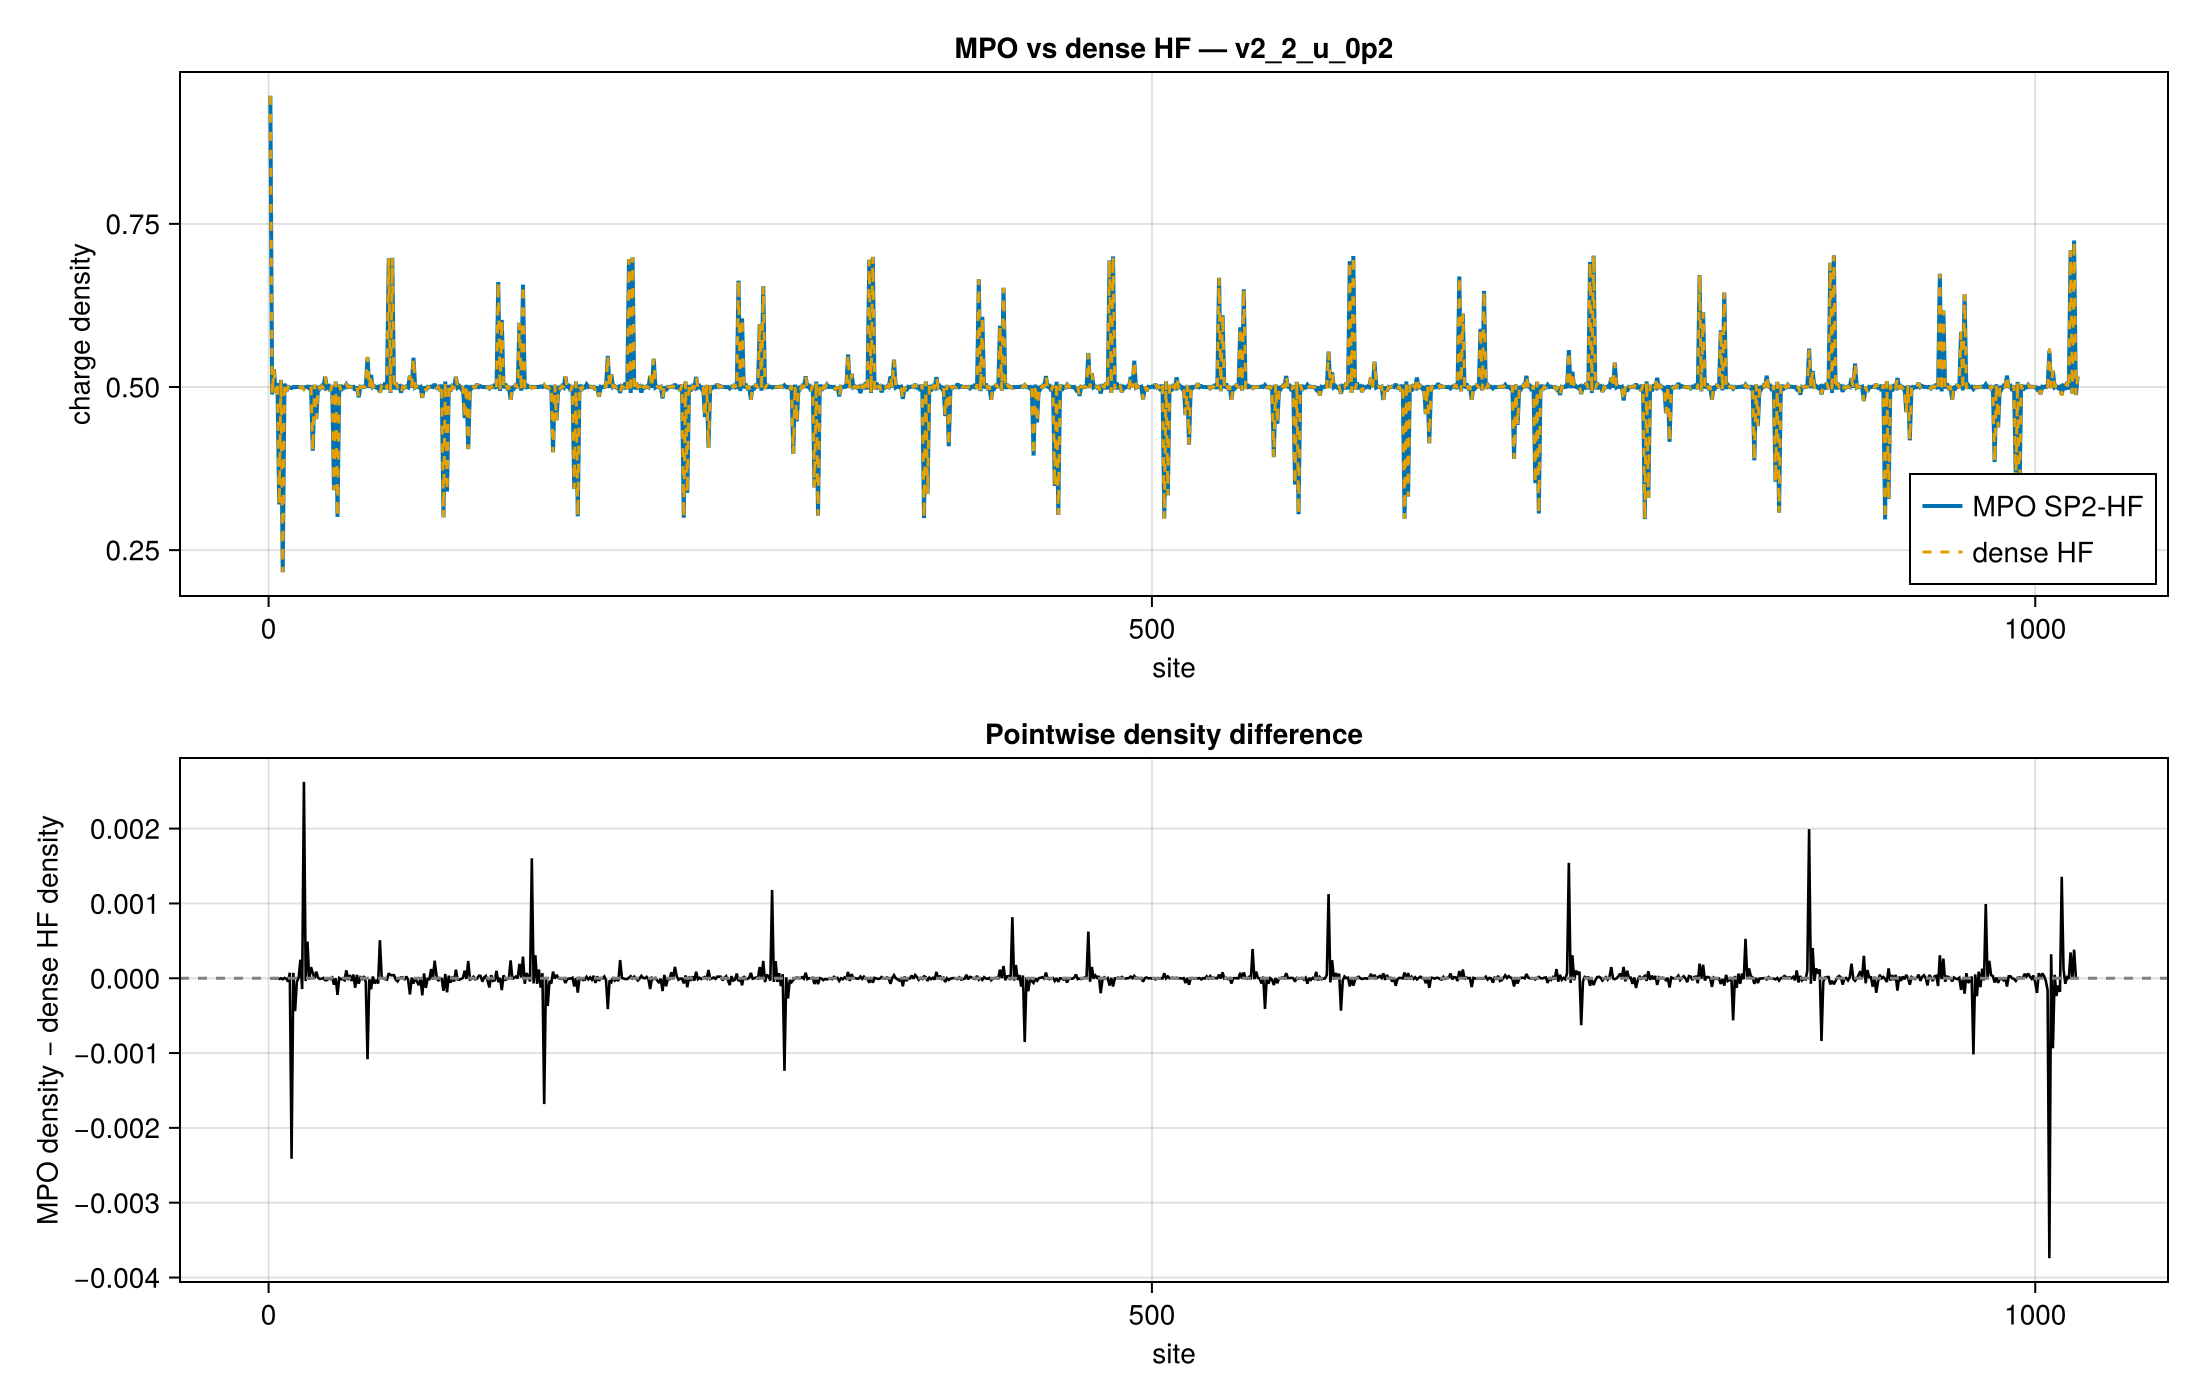

In [44]:
for label in labels
    mpo = mpo_cases[label]
    dense = dense_cases[label]
    Δn = mpo.density .- dense.density

    fig = Figure(size=(1100, 700))

    ax_density = Axis(
        fig[1, 1],
        xlabel="site",
        ylabel="charge density",
        title="MPO vs dense HF — $label",
    )
    lines!(ax_density, mpo.sites, mpo.density; label="MPO SP2-HF", linewidth=2)
    lines!(ax_density, dense.sites, dense.density;
           label="dense HF", linewidth=1.5, linestyle=:dash)
    axislegend(ax_density; position=:rb)

    ax_difference = Axis(
        fig[2, 1],
        xlabel="site",
        ylabel="MPO density − dense HF density",
        title="Pointwise density difference",
    )
    lines!(ax_difference, mpo.sites, Δn; color=:black, linewidth=1.3)
    hlines!(ax_difference, [0.0]; color=:gray, linestyle=:dash)

    display(fig)
end